# Function 4 Analysis - Week 10

1. **Function description (unchanged):**  
Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

2. **Week 9 evaluated point:** `(0.425755, 0.309300, 0.301800, 0.433700)` returned **≈-1.3668**, so this was a **poor point** versus the incumbent best (≈0.5518).

3. **Analysis of last point:** The outcome is dramatically worse than the best-so-far region, so this evaluation does not support moving away from the incumbent basin.

4. **Why we chose last week’s point (from Week 9 logic):** Looking back at Week 9, this appears to be a copy-paste mismatch: the Week 9 notebook recommends `0.398482-0.354755-0.383618-0.397336`, not the evaluated point above. So this week’s poor result likely reflects evaluating the wrong carried-over point, not the intended Week 9 recommendation quality.

5. **Recommendation for this week (and why):** Assume **modest noise** and focus on **exploitation** around the current highest point. Use a local GP model and choose the next point near the incumbent with high predicted mean (limited exploration), rather than broad Thompson-style probing.

## Loading and Displaying the Data

We load the inputs and outputs for function 4. Week 9 `(0.425755, 0.309300, 0.301800, 0.433700)` returned **≈-1.3668** and has been added to the dataset.


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_4")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.100000, 0.400000, 0.400000, 0.050000]])
y_new_point_week_1 = np.array([-11.551402216263181])
X_new_point_week_2 = np.array([[0.412000, 0.448200, 0.386300, 0.439500]])
y_new_point_week_2 = np.array([-0.05797573871593498])
X_new_point_week_3 = np.array([[0.426200, 0.452700, 0.391900, 0.429300]])
y_new_point_week_3 = np.array([-0.013999616551390925])
X_new_point_week_4 = np.array([[0.430000, 0.455200, 0.393800, 0.427600]])
y_new_point_week_4 = np.array([-0.09998342305973962])
X_new_point_week_5 = np.array([[0.430300, 0.359300, 0.351800, 0.383700]])
y_new_point_week_5 = np.array([0.5518426262369016])
X_new_point_week_6 = np.array([[0.421100, 0.389600, 0.370500, 0.393100]])
y_new_point_week_6 = np.array([0.37109387744135747])
X_new_point_week_7 = np.array([[0.440000, 0.390769, 0.330000, 0.410000]])
y_new_point_week_7 = np.array([-0.05018491923068735])
X_new_point_week_8 = np.array([[0.436923, 0.340000, 0.380000, 0.407241]])
y_new_point_week_8 = np.array([0.26196137938032793])
X_new_point_week_9 = np.array([[0.425755, 0.309300, 0.301800, 0.433700]])
y_new_point_week_9 = np.array([-1.36678705398441])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"])
df["y"] = y

# Display original and y-sorted DataFrames side by side
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633
5,0.801303,0.500231,0.706645,0.195103,-15.487083
6,0.247708,0.060445,0.042186,0.441324,-12.681685
7,0.746702,0.757092,0.369353,0.206566,-16.026400
8,0.400665,0.072574,0.886768,0.243842,-17.049235
9,0.626071,0.586751,0.438806,0.778858,-12.741766


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.430300,0.359300,0.351800,0.383700,0.551843,0.381275
1,0.421100,0.389600,0.370500,0.393100,0.371094,0.393575
2,0.436923,0.340000,0.380000,0.407241,0.261961,0.391041
3,0.426200,0.452700,0.391900,0.429300,-0.014000,0.425025
4,0.440000,0.390769,0.330000,0.410000,-0.050185,0.392692
5,0.412000,0.448200,0.386300,0.439500,-0.057976,0.421500
6,0.430000,0.455200,0.393800,0.427600,-0.099983,0.426650
7,0.425755,0.309300,0.301800,0.433700,-1.366787,0.367639
8,0.577766,0.428772,0.425826,0.249007,-4.025542,0.420343
9,0.326076,0.472367,0.453192,0.105887,-6.702089,0.339381


## Weekly Optimization Progress Summary

Overview of all 8 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [ ]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8,
            X_new_point_week_9]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8,
            y_new_point_week_9]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(df_weeks['y'].iloc[0] - 1)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 110)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 110)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,y,Running_Max,Status,Improvement
0,1,0.100000,0.400000,0.4000,0.050000,-11.551402,-11.551402,✓ NEW MAX,+1.000000
1,2,0.412000,0.448200,0.3863,0.439500,-0.057976,-0.057976,✓ NEW MAX,+11.493426
2,3,0.426200,0.452700,0.3919,0.429300,-0.014000,-0.014000,✓ NEW MAX,+0.043976
3,4,0.430000,0.455200,0.3938,0.427600,-0.099983,-0.014000,✗,-
4,5,0.430300,0.359300,0.3518,0.383700,0.551843,0.551843,✓ NEW MAX,+0.565842
5,6,0.421100,0.389600,0.3705,0.393100,0.371094,0.551843,✗,-
6,7,0.440000,0.390769,0.3300,0.410000,-0.050185,0.551843,✗,-
7,8,0.436923,0.340000,0.3800,0.407241,0.261961,0.551843,✗,-
8,9,0.425755,0.309300,0.3018,0.433700,-1.366787,0.551843,✗,-



📊 Summary: 4/9 weeks achieved new max (Weeks [1, 2, 3, 5])
   Success rate: 44.4% | Final best: 0.551843


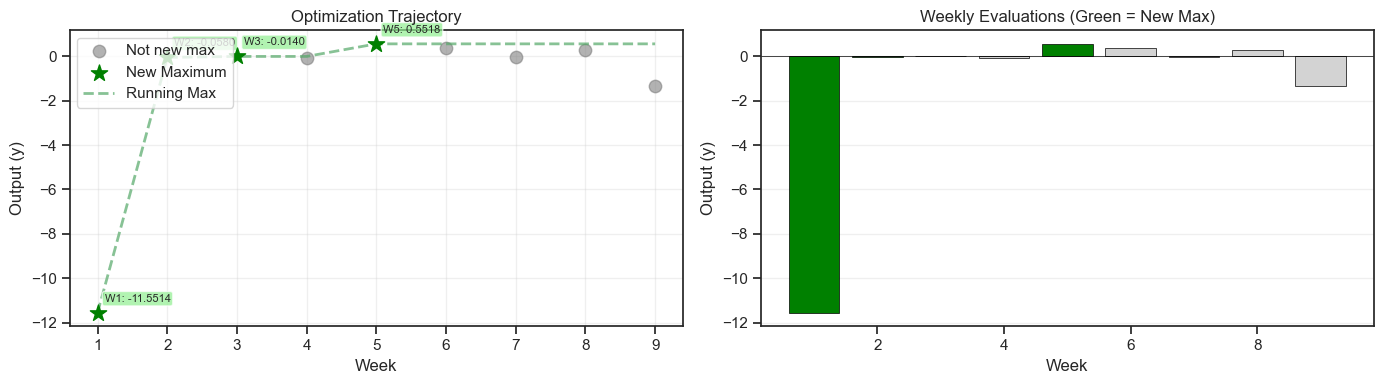

In [ ]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Thompson Sampling for Noisy Multi-Modal Landscape

The function is described as "full of local optima" and noisy. Thompson Sampling handles this by:
1. Fitting a GP with explicit noise modeling
2. Drawing random samples from the posterior (not just using the mean)
3. Picking points that look promising across multiple samples

This naturally balances exploration and exploitation without getting trapped.


In [ ]:
# Thompson Sampling for noisy, multi-modal optimization
# ======================================================
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Current best point
best_idx = df['y'].idxmax()
best_point = df.loc[best_idx]
best_x1, best_x2, best_x3, best_x4 = best_point['x1'], best_point['x2'], best_point['x3'], best_point['x4']
best_y = best_point['y']

print(f"Current best: ({best_x1:.4f}, {best_x2:.4f}, {best_x3:.4f}, {best_x4:.4f}) = {best_y:.4f}")
print(f"Week 8 point: (0.4369, 0.3400, 0.3800, 0.4072) = 0.262\n")
print("Note: Function is 'full of local optima' — we might be in a local trap!\n")

# Search region: moderate width to allow escape from potential local optimum
search_radius = 0.05  # ±0.05 in each dimension (wider than tight TuRBO)
sr_x1_min, sr_x1_max = max(0, best_x1 - search_radius), min(1, best_x1 + search_radius)
sr_x2_min, sr_x2_max = max(0, best_x2 - search_radius), min(1, best_x2 + search_radius)
sr_x3_min, sr_x3_max = max(0, best_x3 - search_radius), min(1, best_x3 + search_radius)
sr_x4_min, sr_x4_max = max(0, best_x4 - search_radius), min(1, best_x4 + search_radius)

print(f"Search region (±{search_radius}):")
print(f"  x1 ∈ [{sr_x1_min:.3f}, {sr_x1_max:.3f}]")
print(f"  x2 ∈ [{sr_x2_min:.3f}, {sr_x2_max:.3f}]")
print(f"  x3 ∈ [{sr_x3_min:.3f}, {sr_x3_max:.3f}]")
print(f"  x4 ∈ [{sr_x4_min:.3f}, {sr_x4_max:.3f}]\n")

# Fit GP with higher noise tolerance (function is noisy!)
kernel = (
    ConstantKernel(1.0, (1e-2, 100.0))
    * Matern(length_scale=[0.1, 0.1, 0.1, 0.1], length_scale_bounds=(0.01, 0.5), nu=2.5)
    + WhiteKernel(noise_level=0.1, noise_level_bounds=(0.01, 1.0))  # High noise!
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X, y)
print(f"GP fitted. Kernel: {gp.kernel_}\n")

# Generate candidate grid within search region
grid_res = 12  # 12^4 = 20,736 candidates
grid_x1 = np.linspace(sr_x1_min, sr_x1_max, grid_res)
grid_x2 = np.linspace(sr_x2_min, sr_x2_max, grid_res)
grid_x3 = np.linspace(sr_x3_min, sr_x3_max, grid_res)
grid_x4 = np.linspace(sr_x4_min, sr_x4_max, grid_res)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3, grid_x4)).reshape(4, -1).T

print(f"Evaluating {len(mesh)} candidates...")

# Get GP predictions (mean and std)
mu, sigma = gp.predict(mesh, return_std=True)

# Thompson Sampling: draw multiple posterior samples, count wins
n_samples = 50
np.random.seed(42)
win_counts = np.zeros(len(mesh))

for _ in range(n_samples):
    # Sample from posterior: y_sample ~ N(mu, sigma^2)
    samples = mu + sigma * np.random.randn(len(mesh))
    winner = np.argmax(samples)
    win_counts[winner] += 1

print(f"Thompson Sampling: drew {n_samples} posterior samples")

# Build candidate dataframe
candidates = pd.DataFrame(mesh, columns=['x1', 'x2', 'x3', 'x4'])
candidates['mu'] = mu
candidates['sigma'] = sigma
candidates['wins'] = win_counts
candidates['win_rate'] = win_counts / n_samples

# Filter 1: must be at least 0.015 away from any existing observation
min_dist = 0.015
for _, obs in df.iterrows():
    dist = np.sqrt((candidates['x1'] - obs['x1'])**2 + 
                   (candidates['x2'] - obs['x2'])**2 +
                   (candidates['x3'] - obs['x3'])**2 +
                   (candidates['x4'] - obs['x4'])**2)
    candidates = candidates[dist >= min_dist]

print(f"Candidates after distance filter (≥{min_dist} from obs): {len(candidates)}")

# Filter 2: GP mean must be reasonable (not too far below best)
# Without this, Thompson Sampling picks high-uncertainty edges with terrible expected values
mu_threshold = best_y - 0.5  # Don't consider candidates with mu more than 0.5 below best
candidates_filtered = candidates[candidates['mu'] >= mu_threshold].copy()
print(f"Candidates after GP mean filter (μ ≥ {mu_threshold:.2f}): {len(candidates_filtered)}")

# If no candidates pass the mean filter, fall back to UCB ranking on all candidates
if len(candidates_filtered) < 5:
    print("\\nWarning: Few candidates pass mean filter. Using UCB ranking instead.")
    candidates['ucb'] = candidates['mu'] + 0.5 * candidates['sigma']
    top_candidates = candidates.nlargest(10, 'ucb')
    print("\\nTop 10 candidates (by UCB, since Thompson Sampling was too exploratory):")
else:
    # Re-run Thompson Sampling on filtered candidates only
    candidates_filtered['wins'] = 0
    mesh_filtered = candidates_filtered[['x1', 'x2', 'x3', 'x4']].values
    mu_filtered = candidates_filtered['mu'].values
    sigma_filtered = candidates_filtered['sigma'].values
    
    win_counts_filtered = np.zeros(len(candidates_filtered))
    for _ in range(n_samples):
        samples = mu_filtered + sigma_filtered * np.random.randn(len(mu_filtered))
        winner = np.argmax(samples)
        win_counts_filtered[winner] += 1
    
    candidates_filtered['wins'] = win_counts_filtered
    candidates_filtered['win_rate'] = win_counts_filtered / n_samples
    top_candidates = candidates_filtered.nlargest(10, 'wins')
    print("\\nTop 10 Thompson Sampling candidates (filtered, by win count):")

display(top_candidates)

# Recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    print(f"\n" + "="*60)
    print("THOMPSON SAMPLING RECOMMENDATION")
    print("="*60)
    print(f"Recommended point: ({rec['x1']:.6f}, {rec['x2']:.6f}, {rec['x3']:.6f}, {rec['x4']:.6f})")
    print(f"GP prediction: μ={rec['mu']:.4f}, σ={rec['sigma']:.4f}")
    print(f"Win rate: {rec['win_rate']:.1%} ({int(rec['wins'])}/{n_samples} samples)")
    print(f"\nSubmission format: {rec['x1']:.6f}-{rec['x2']:.6f}-{rec['x3']:.6f}-{rec['x4']:.6f}")
else:
    print("\nNo valid candidates found - try expanding search region")


Current best: (0.4303, 0.3593, 0.3518, 0.3837) = 0.5518
Week 8 point: (0.4369, 0.3400, 0.3800, 0.4072) = 0.262

Note: Function is 'full of local optima' — we might be in a local trap!

Search region (±0.05):
  x1 ∈ [0.380, 0.480]
  x2 ∈ [0.309, 0.409]
  x3 ∈ [0.302, 0.402]
  x4 ∈ [0.334, 0.434]



d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a bette

GP fitted. Kernel: 0.855**2 * Matern(length_scale=[0.5, 0.5, 0.5, 0.5], nu=2.5) + WhiteKernel(noise_level=0.01)

Evaluating 20736 candidates...
Thompson Sampling: drew 50 posterior samples
Candidates after distance filter (≥0.015 from obs): 20602
Candidates after GP mean filter (μ ≥ 0.05): 3440
\nTop 10 Thompson Sampling candidates (filtered, by win count):


,x1,x2,x3,x4,mu,sigma,wins,win_rate
9789,0.443936,0.354755,0.401800,0.415518,0.071604,1.166226,1.0,0.02
11351,0.434845,0.363845,0.383618,0.433700,0.130357,1.102893,1.0,0.02
11503,0.443936,0.363845,0.392709,0.397336,0.179515,1.090676,1.0,0.02
11782,0.462118,0.363845,0.383618,0.424609,0.087953,1.138374,1.0,0.02
11792,0.462118,0.363845,0.392709,0.406427,0.109392,1.132452,1.0,0.02
12380,0.389391,0.372936,0.401800,0.406427,0.072600,1.204756,1.0,0.02
12489,0.398482,0.372936,0.374527,0.415518,0.148412,1.087006,1.0,0.02
12646,0.407573,0.372936,0.383618,0.424609,0.176998,1.089683,1.0,0.02
12919,0.425755,0.372936,0.374527,0.397336,0.257416,1.025197,1.0,0.02
13353,0.453027,0.372936,0.374527,0.415518,0.210246,1.056721,1.0,0.02



THOMPSON SAMPLING RECOMMENDATION
Recommended point: (0.443936, 0.354755, 0.401800, 0.415518)
GP prediction: μ=0.0716, σ=1.1662
Win rate: 2.0% (1/50 samples)

Submission format: 0.443936-0.354755-0.401800-0.415518


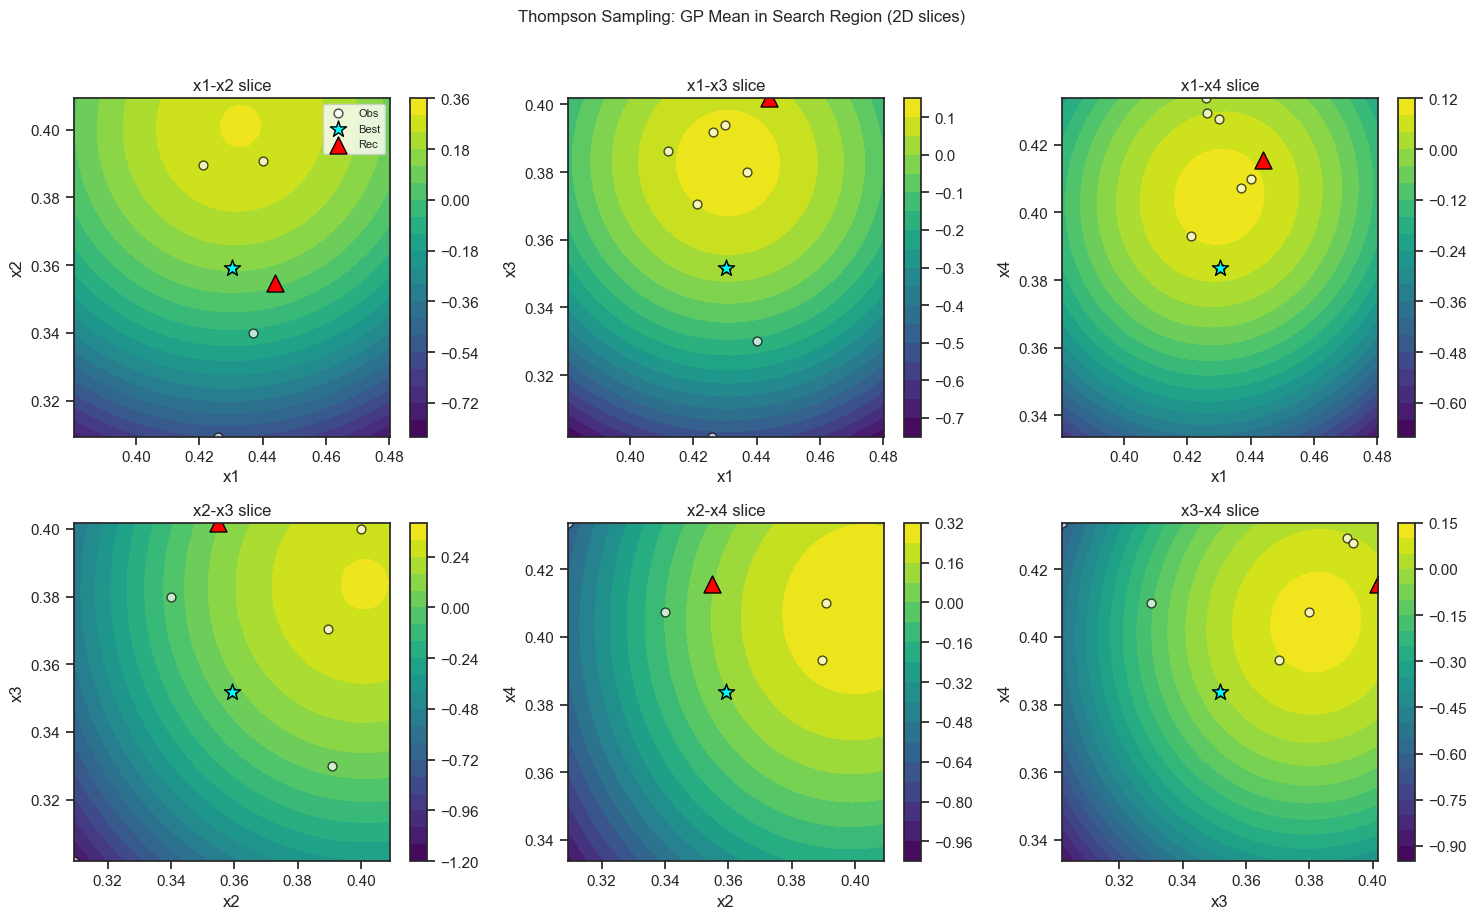

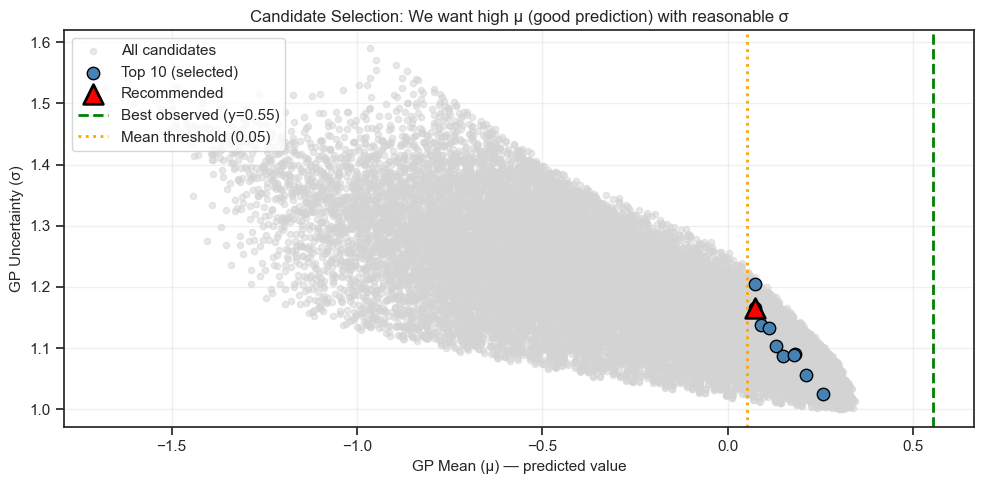

In [ ]:
# Visualization: Thompson Sampling results
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

# Get recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    rec_x = {'x1': rec['x1'], 'x2': rec['x2'], 'x3': rec['x3'], 'x4': rec['x4']}
else:
    rec_x = {'x1': best_x1, 'x2': best_x2, 'x3': best_x3, 'x4': best_x4}

# 6 pairwise 2D slices
pairs = [(0, 1, 'x1', 'x2'), (0, 2, 'x1', 'x3'), (0, 3, 'x1', 'x4'),
         (1, 2, 'x2', 'x3'), (1, 3, 'x2', 'x4'), (2, 3, 'x3', 'x4')]

sr_bounds = {'x1': (sr_x1_min, sr_x1_max), 'x2': (sr_x2_min, sr_x2_max), 
             'x3': (sr_x3_min, sr_x3_max), 'x4': (sr_x4_min, sr_x4_max)}

for ax_idx, (i, j, label_i, label_j) in enumerate(pairs):
    ax = axes[ax_idx]
    
    # Create 2D grid for this pair
    slice_res = 30
    xi_grid = np.linspace(sr_bounds[label_i][0], sr_bounds[label_i][1], slice_res)
    xj_grid = np.linspace(sr_bounds[label_j][0], sr_bounds[label_j][1], slice_res)
    xxi, xxj = np.meshgrid(xi_grid, xj_grid)
    
    # Build full 4D points for prediction (use column order: x1, x2, x3, x4)
    slice_pts = np.zeros((slice_res * slice_res, 4))
    col_map = {'x1': 0, 'x2': 1, 'x3': 2, 'x4': 3}
    slice_pts[:, col_map[label_i]] = xxi.ravel()
    slice_pts[:, col_map[label_j]] = xxj.ravel()
    for col_name in ['x1', 'x2', 'x3', 'x4']:
        if col_name != label_i and col_name != label_j:
            slice_pts[:, col_map[col_name]] = rec_x[col_name]
    
    slice_mu = gp.predict(slice_pts).reshape(xxi.shape)
    
    im = ax.contourf(xxi, xxj, slice_mu, levels=20, cmap='viridis')
    
    # Plot all observations (use column names directly)
    ax.scatter(df[label_i], df[label_j], c='white', edgecolor='black', s=40, alpha=0.7, label='Obs')
    ax.scatter(best_point[label_i], best_point[label_j], c='cyan', edgecolor='black', s=150, marker='*', label='Best')
    ax.scatter(rec_x[label_i], rec_x[label_j], c='red', edgecolor='black', s=150, marker='^', label='Rec')
    
    # Set axis limits to search region
    ax.set_xlim(sr_bounds[label_i])
    ax.set_ylim(sr_bounds[label_j])
    ax.set_xlabel(label_i)
    ax.set_ylabel(label_j)
    ax.set_title(f'{label_i}-{label_j} slice')
    plt.colorbar(im, ax=ax)

axes[0].legend(fontsize=8, loc='upper right')
plt.suptitle('Thompson Sampling: GP Mean in Search Region (2D slices)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Show GP mean vs uncertainty for candidates (more informative than win rate bar chart)
fig2, ax2 = plt.subplots(figsize=(10, 5))

# Plot all candidates that passed distance filter
ax2.scatter(candidates['mu'], candidates['sigma'], c='lightgray', s=20, alpha=0.5, label='All candidates')

# Highlight top candidates
ax2.scatter(top_candidates['mu'], top_candidates['sigma'], c='steelblue', s=80, edgecolor='black', label='Top 10 (selected)')

# Mark the recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    ax2.scatter(rec['mu'], rec['sigma'], c='red', s=200, marker='^', edgecolor='black', linewidth=2, label='Recommended', zorder=10)

# Mark the best observed y value
ax2.axvline(x=best_y, color='green', linestyle='--', linewidth=2, label=f'Best observed (y={best_y:.2f})')

# Add reference line for mean threshold if it was applied
if 'mu_threshold' in dir():
    ax2.axvline(x=mu_threshold, color='orange', linestyle=':', linewidth=2, label=f'Mean threshold ({mu_threshold:.2f})')

ax2.set_xlabel('GP Mean (μ) — predicted value', fontsize=11)
ax2.set_ylabel('GP Uncertainty (σ)', fontsize=11)
ax2.set_title('Candidate Selection: We want high μ (good prediction) with reasonable σ', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Current best:** `0.430300-0.359300-0.351800-0.383700` (≈0.5518)

**Proposed new point (submission format):** `0.443936-0.354755-0.401800-0.415518`

Week 9 evaluated `0.425755-0.309300-0.301800-0.433700` (≈-1.3668), which is clearly inconsistent with the Week 9 recommended point (`0.398482-0.354755-0.383618-0.397336`) and likely came from a copy-paste mismatch. Given that, we treat this as an execution/logging issue rather than evidence against the incumbent region. In this step, we bias toward exploitation around the current highest point, assuming modest noise: stay local to the 0.5518 basin and prefer candidates with stronger predicted mean rather than large uncertainty-driven jumps.